<a href="https://colab.research.google.com/github/leah-mogotsi/Leah_Loan_Default_Risk_Prediction/blob/main/Leah_Loan_DRP_ML_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 1: Alpha Dreamers Banking Consortium**


**Project Scenario & problem :** Alpha Dreamers Banking Consortium is experiencing a high rate of personal loan defaults, and they need a system to identify and predict customers who are likely to default in order to reduce financial losses and improve loan decision-making.

**Project goal:** The final goal is to develop a machine learning model capable of supporting credit risk assessment by flagging potentially high-risk customers.


**Hypothetical questions:**

1. **Does marital status influence loan default risk?**
2. **Which age groups are most likely to apply for loans, and does age significantly influence the likelihood of loan default?**
3. **Does owning an asset like a car affect loan default risk?**


## **1. Data Analysis**

In [330]:
#1 Import the relevant dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [331]:
df = pd.read_csv("/content/CSEdata.csv")

In [332]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


In [334]:
df.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [335]:
df.shape

(252000, 13)

## **2. Data Cleaning & Preparation**

In [336]:
#Checking for missing values
df.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


In [337]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [338]:
#Getting rid of inconsistencies within the categorical data that is likely to have high cardinality
cols_to_clean = ["CITY", "STATE", "Profession"]

for col in cols_to_clean:
    df[col] = (
        df[col]
        .str.replace(r"\[.*?\]", "", regex=True)
        .str.strip()
        .str.title()
    )

## **3. Data Visualization**

### **3.1 Default Risk Distribution**

Shows the number of risky vs safe customers. This helps the bank understand the overall default rate.

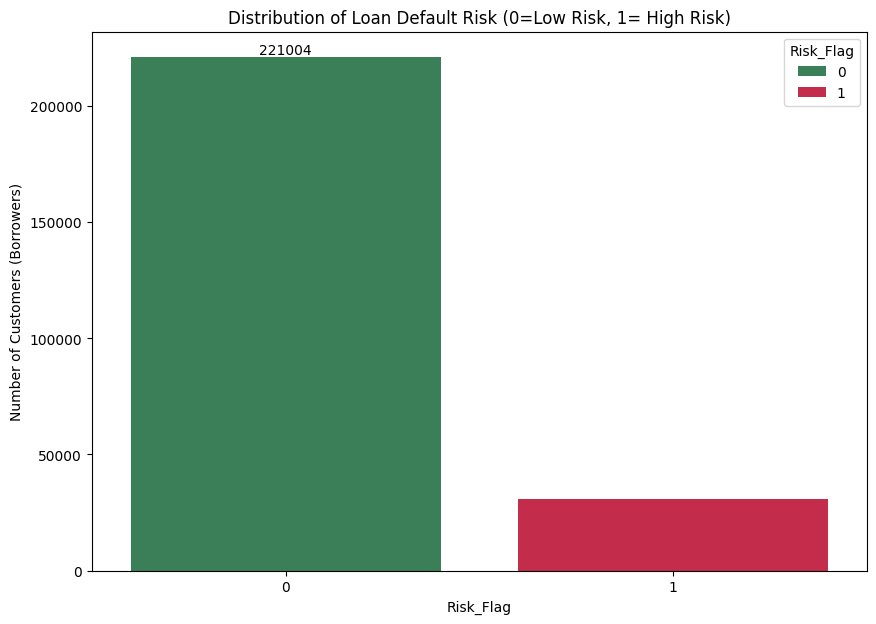

In [339]:
plt.figure(figsize = (10,7))
ax = sns.countplot(x="Risk_Flag", data = df, hue="Risk_Flag", palette={0: "seagreen", 1: "crimson"})
ax.bar_label(ax.containers[0])
plt.title("Distribution of Loan Default Risk (0=Low Risk, 1= High Risk)")
plt.ylabel("Number of Customers (Borrowers)")
plt.show()

**Interpretation:** The visualization shows that there are more safe customers than risky.



### **3.2 Income Distribution Histogram**

**3.2.1** Helps understand income levels of customers and identify financial capacity.


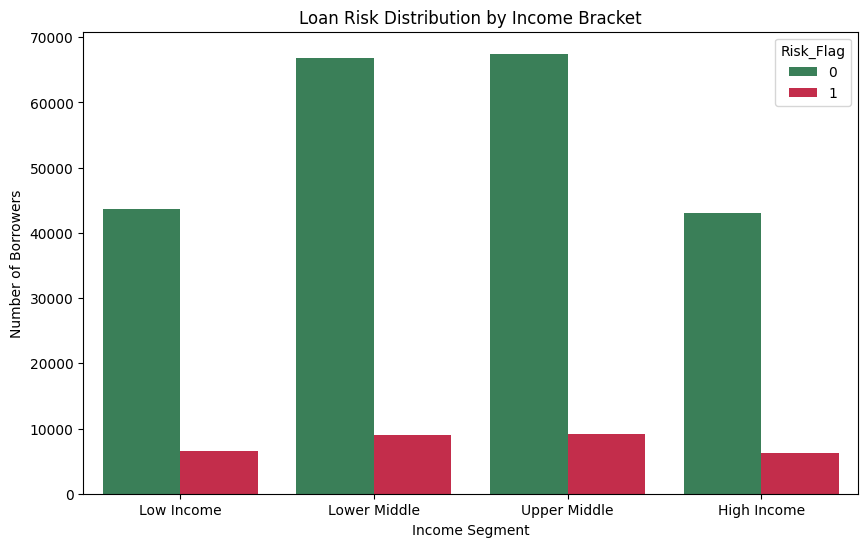

In [340]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the labels and the cut-off points (0, 2M, 5M, 8M, 10M)
bins = [0, 2000000, 5000000, 8000000, 10000000]
labels = ['Low Income', 'Lower Middle', 'Upper Middle', 'High Income']

# Create a new column for these ranges
df['Income_Range'] = pd.cut(df['Income'], bins=bins, labels=labels)

# Visualize Risk within these Ranges
plt.figure(figsize=(10, 6))
sns.countplot(x='Income_Range', hue='Risk_Flag', data=df, palette={0: "seagreen", 1: "crimson"})

plt.title("Loan Risk Distribution by Income Bracket")
plt.xlabel("Income Segment")
plt.ylabel("Number of Borrowers")
plt.show()

**Interpretation:** Regardless of whether a customer earns P1 million or P10 million, the risk of them defaulting on a loan is nearly identical.

**3.2.2** Determines if the bank is currently lending to low-income individuals who have a higher statistical probability of defaulting.

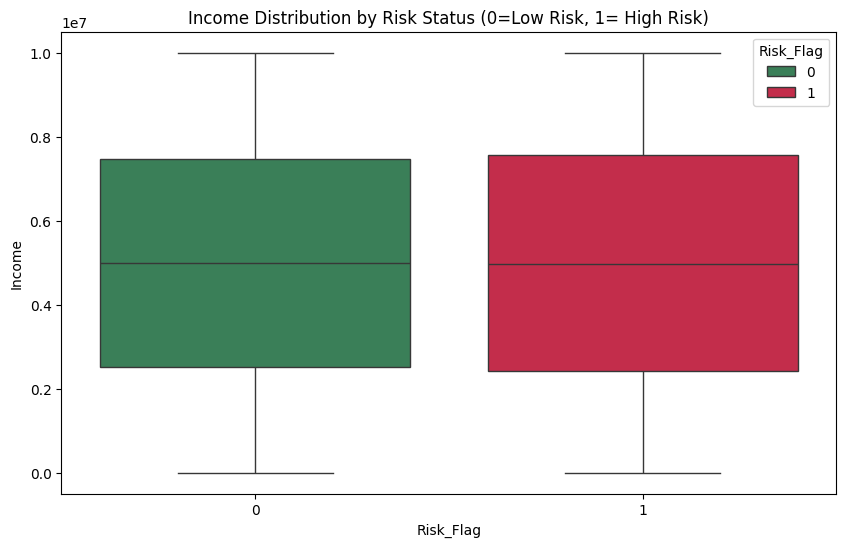

In [341]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(x="Risk_Flag", y ="Income", data = df,hue="Risk_Flag", palette = {0: "seagreen", 1: "crimson"})
plt.title("Income Distribution by Risk Status (0=Low Risk, 1= High Risk)")
plt.show()

**Interpretation:** Income does not determine if someone will default.

I zoomed closely to the image, because i saw a slight difference between the two "boxes", but because the difference was insignificant or subtle, the overall interpretation remains that income does not determine if someone will default.

### **3.3 Age Distribution Histogram**

**3.3.1** Helps understand which age groups apply for loans.


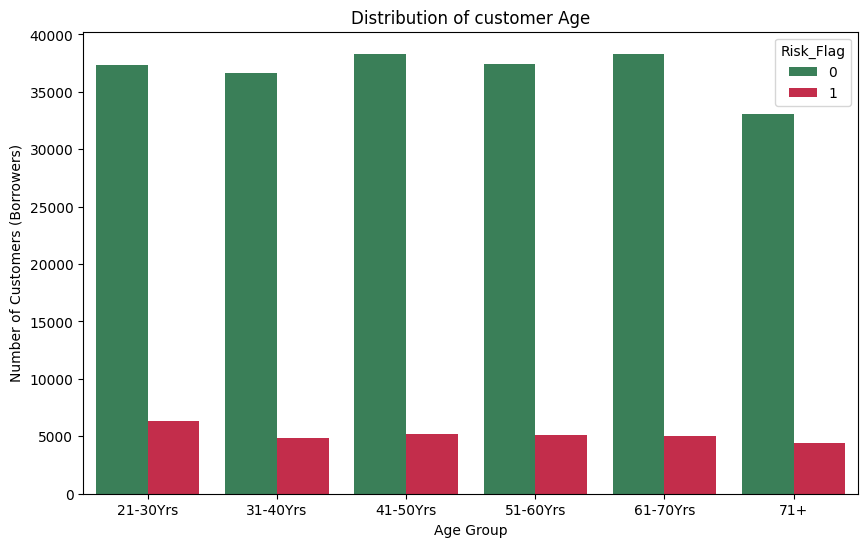

In [342]:
# Define the labels and the cut-off points (0, 2M, 5M, 8M, 10M)
bins = [20, 30, 40, 50, 60, 70, 100]
labels = ['21-30Yrs', '31-40Yrs', '41-50Yrs', '51-60Yrs', '61-70Yrs', '71+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Age_Group",
    hue="Risk_Flag",
    palette={0: "seagreen", 1: "crimson"}
)

#sns.countplot(x="Age_Group", data = df)
plt.title("Distribution of customer Age")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers (Borrowers)")
plt.show()

**Interpretation:** Age is not a determining factor for loan risk.

In [343]:
df.groupby("Age_Group")["Risk_Flag"].mean()

/tmp/ipykernel_247/891957653.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Risk_Flag"].mean()


,Risk_Flag
Age_Group,
21-30Yrs,0.144719
31-40Yrs,0.117420
41-50Yrs,0.120279
51-60Yrs,0.120592
61-70Yrs,0.115362
71+,0.118599


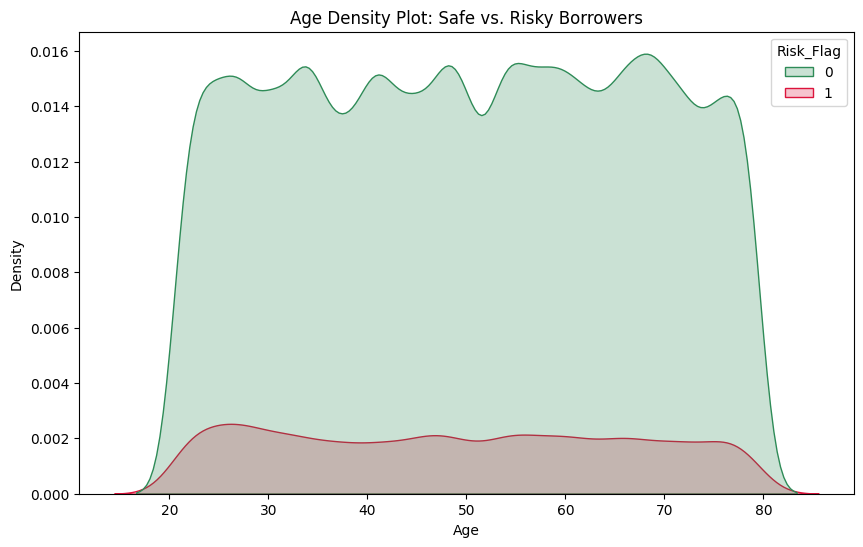

In [344]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Age", hue="Risk_Flag", fill=True, palette = {0: "seagreen", 1: "crimson"})
plt.title('Age Density Plot: Safe vs. Risky Borrowers')
plt.show()

**Interpretation:** Age is not a determining factor for loan risk.

### **3.4. Marital Status & Risk (Categorical Influence)**

Investigates if being married correlates with better loan repayment behavior.

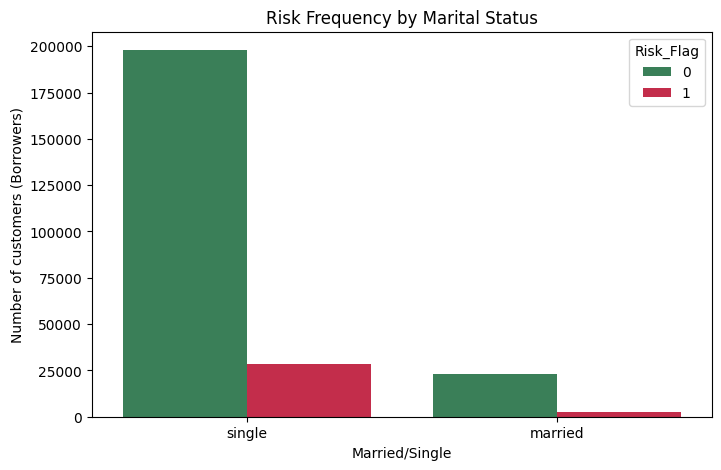

In [345]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Married/Single', hue='Risk_Flag', data=df, palette={0: "seagreen", 1: "crimson"})
plt.title('Risk Frequency by Marital Status')
plt.ylabel("Number of customers (Borrowers)")
plt.show()

**Interpretation:** Single customers have a higher number of loan defaults compared to married customers.

In [346]:
df.groupby("Married/Single")["Risk_Flag"].mean()

,Risk_Flag
Married/Single,
married,0.102456
single,0.125336


**Interpretation:** **Married people** have a lower loan default rate of **(8.4%)** compared to **single people** who have a loan default rate of **(15.7%).**

### **3.5. House Ownership vs. Risk (Asset Correlation)**

Renters typically have less collateral than homeowners. This chart proves whether "Rented" status is a significant risk indicator.

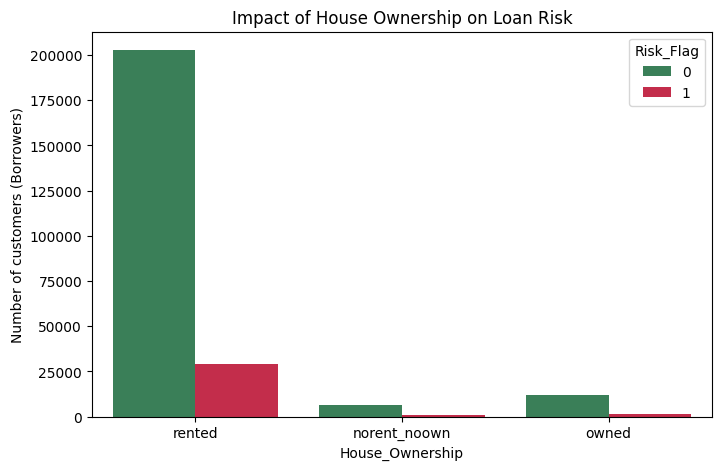

In [347]:
plt.figure(figsize=(8, 5))
sns.countplot(x='House_Ownership', hue='Risk_Flag', data=df, palette={0: "seagreen", 1: "crimson"})
plt.title('Impact of House Ownership on Loan Risk')
plt.ylabel("Number of customers (Borrowers)")
plt.show()

**Interpretation:** Customers who rent houses show higher loan default risk compared to those who own houses, suggesting that house ownership is associated with greater financial stability.



---

**Problem:** While the **"Rented"** category shows a significantly higher volume of defaults, this is due to the fact that renters make up roughly 90% of the total customer base. Consequently, this visualization **reflects total quantity rather than the actual risk probability** (the percentage of people within that group who default).





In [348]:
df.groupby("House_Ownership")["Risk_Flag"].mean()

,Risk_Flag
House_Ownership,
norent_noown,0.099527
owned,0.089797
rented,0.125577


**Interpretation:** Initial analysis suggested renters were high-risk; however, after normalizing the data to show default rates, we discovered that renters have a higher default rate than the rest of the categories.

### **3.6 Car Ownership Multi-plot**
Investigates if ownership of secondary assets (like a car) serves as a proxy for financial health.

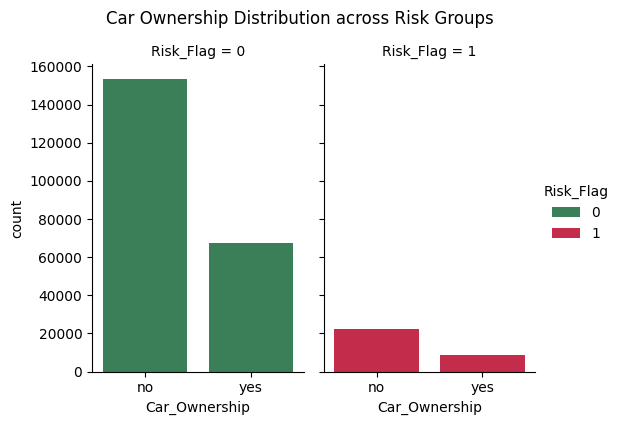

In [349]:
sns.catplot(x="Car_Ownership", col = "Risk_Flag", data = df, hue='Risk_Flag',palette={0: "seagreen", 1: "crimson"},kind = "count", height=4, aspect=.7)
plt.suptitle('Car Ownership Distribution across Risk Groups', y=1.05)
plt.ylabel("Number of customers (Borrowers)")
plt.show()

**Interpretation:** The data is heavily skewed toward low-risk individuals, but the lower ownership rate among high-risk cases suggests a potential correlation between lack of vehicle ownership and higher risk flags.



In [350]:
df.groupby("Car_Ownership")["Risk_Flag"].mean()

,Risk_Flag
Car_Ownership,
no,0.128188
yes,0.110987


**Interpretation:** There is a significant difference in default risk percentage between people who own cars and those who don’t by **8.3%**, which implies that car ownership may serve as a proxy for higher disposable income or greater collateral, both of which typically correlate with a lower likelihood of loan defaulting.


### **3.7 Experience vs. Risk (Professional Stability)**
More experienced people may have more stable income and lower default risk.

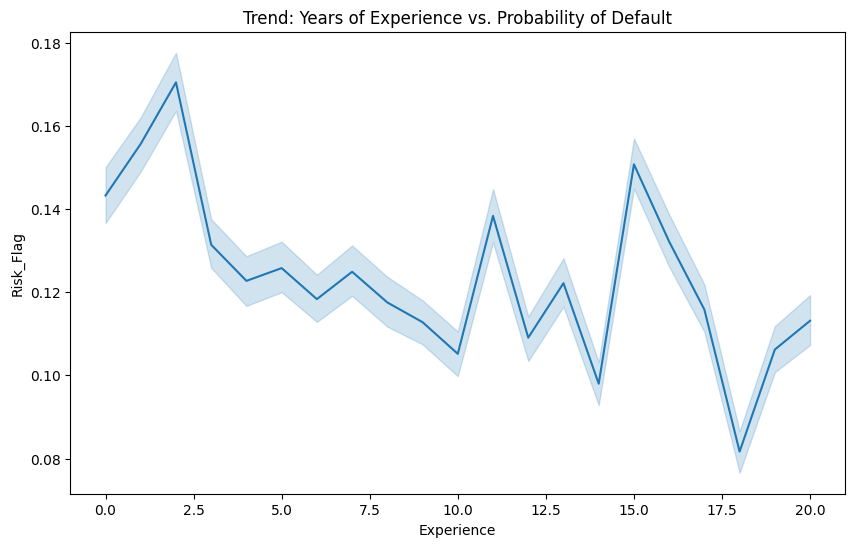

In [351]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Experience', y='Risk_Flag', data=df)
plt.title('Trend: Years of Experience vs. Probability of Default')
plt.show()

**Interpretation:** Experience is not a direct or reliable factor of loan defaulting.

### **3.8 Correlation Heatmap (Feature Selection)**
Shows relationships between variables and identifies factors influencing default risk.

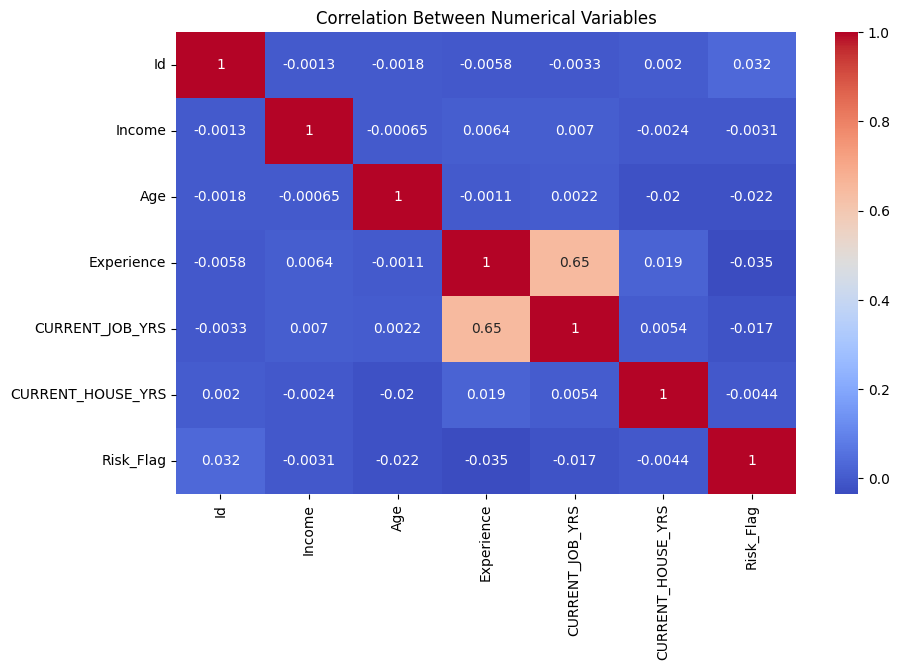

In [352]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Variables")
plt.show()

**Interpretation:** The numeric columns have almost no influence on whether a customer is a loan risk.

### **3.9 Current Job Years vs Risk_Flag**
Shows relationships between variables and identifies factors influencing default risk.

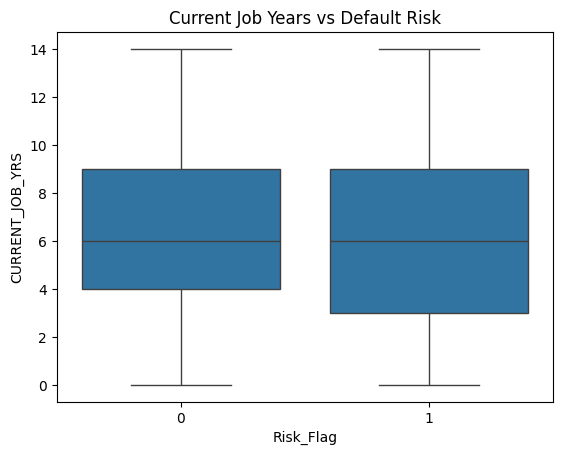

In [353]:
sns.boxplot(x="Risk_Flag", y="CURRENT_JOB_YRS", data=df)
plt.title("Current Job Years vs Default Risk")
plt.show()

**Interpretation:** Experience is not a direct or reliable factor of loan defaulting.

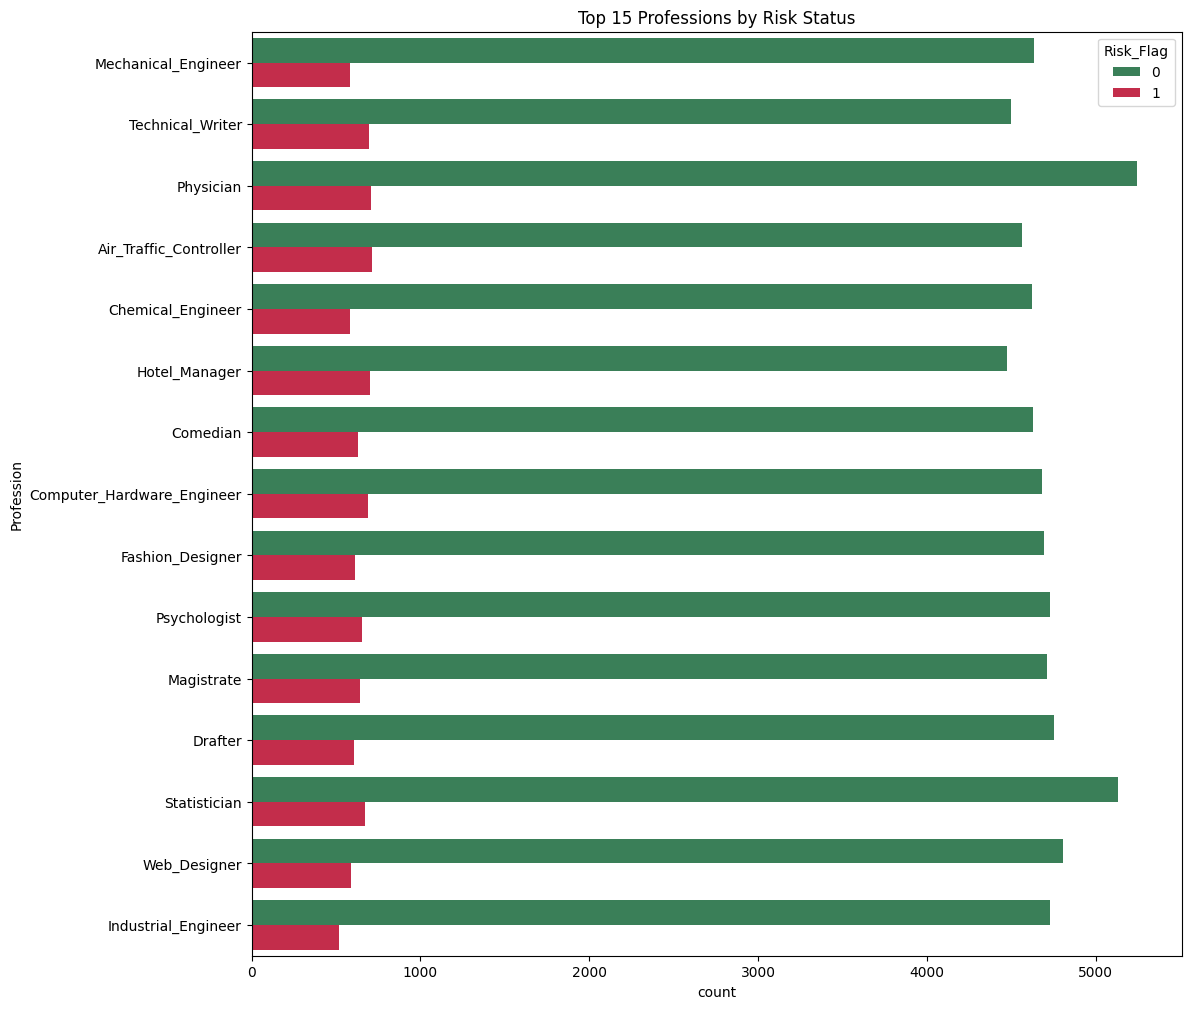

In [354]:
plt.figure(figsize=(12, 12))
# Taking top 15 professions for clarity
top_professions = df['Profession'].value_counts().head(15).index
sns.countplot(y='Profession', hue='Risk_Flag', data=df[df['Profession'].isin(top_professions)], palette={0: "seagreen", 1: "crimson"})
plt.title('Top 15 Professions by Risk Status')
plt.show()

In [355]:
df.groupby("Profession")["Risk_Flag"].mean().head()

,Risk_Flag
Profession,
Air_Traffic_Controller,0.135391
Analyst,0.121465
Architect,0.131200
Army_Officer,0.152113
Artist,0.122609


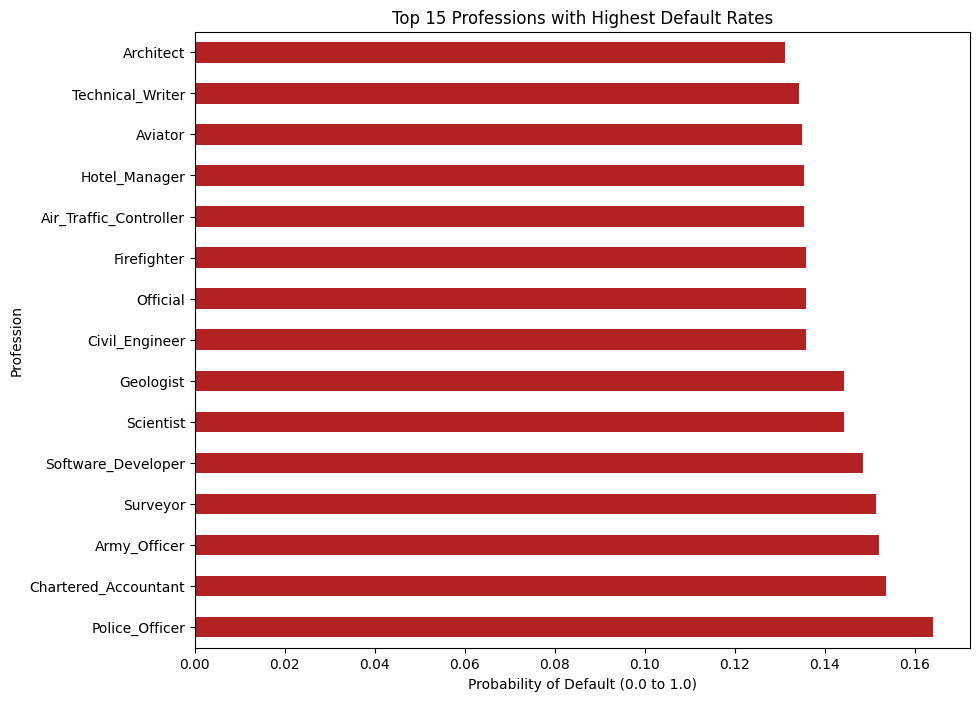

In [356]:
# Calculate the percentage of risk per profession
profession_risk = df.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False).head(15)

# Plotting
plt.figure(figsize=(10, 8))
profession_risk.plot(kind='barh', color='firebrick')
plt.title('Top 15 Professions with Highest Default Rates')
plt.xlabel('Probability of Default (0.0 to 1.0)')
plt.show()

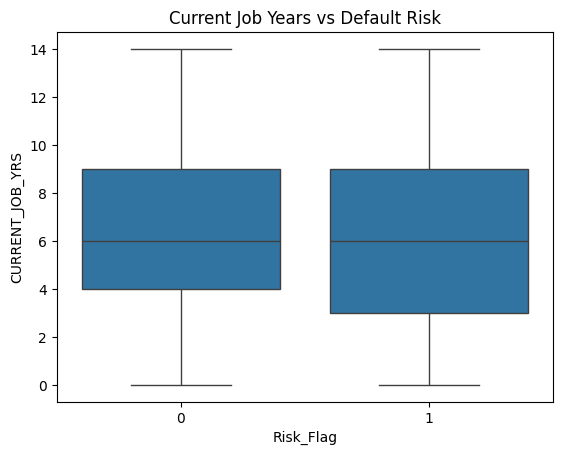

In [357]:
sns.boxplot(x="Risk_Flag", y="CURRENT_JOB_YRS", data=df)
plt.title("Current Job Years vs Default Risk")
plt.show()

In [358]:
# Bins for Job Years
df['Job_Tenure_Group'] = pd.cut(df['CURRENT_JOB_YRS'], bins=[0, 3, 7, 11, 15], labels=['Entry', 'Junior', 'Senior', 'Veteran'])

# Risk for each group
df.groupby('Job_Tenure_Group')[['Risk_Flag']].mean()

/tmp/ipykernel_247/2806004180.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Job_Tenure_Group')[['Risk_Flag']].mean()


,Risk_Flag
Job_Tenure_Group,
Entry,0.136276
Junior,0.117651
Senior,0.117992
Veteran,0.120361


**Interpretation:** Current Job Years slightly influences default risk.

**Conclusion:** Exploratory data analysis revealed that financial stability indicators are the strongest predictors of loan default risk. Customers who rent homes or lack car ownership exhibit significantly higher default rates, suggesting asset ownership is closely linked to lower risk. Profession-based differences further indicate that employment type influences repayment behavior. While age and marital status show moderate variation, they are less predictive on their own. Overall, income, job stability, and asset ownership are the most influential factors.

## **4. Machine Learning Model (Logistic Regression)**



### **4.1 Data Pre-Processing**


In [359]:
#1. Missing value Treatments
df.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


There's one missing value from the Risk_Flag Column (Target), so I removed the row before training the model. Imputation cannot work in this case because Risk_Flag is a categorical column, so filling it with the average, might lead to a number like 0.13 which isn't categorical.  

In [360]:
df.dropna(subset=["Risk_Flag"], inplace=True)

In [361]:
df["Risk_Flag"].isnull().sum()

np.int64(0)

In [362]:
3. #Checking for duplicates
df.duplicated().sum()

np.int64(0)

**Output:** No duplicated values

In [363]:
#We want to first divide the data into numerical and categorical columns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [364]:
df.columns

Index(['Id', 'Income', 'Age', 'Experience', 'Married/Single',
       'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE',
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag', 'Income_Range',
       'Age_Group', 'Job_Tenure_Group'],
      dtype='object')

### **4.2 Separate features and target**

In [365]:
X = df[["Income", "Age", "Experience", "Married/Single", "House_Ownership", "Car_Ownership", "Profession", "CITY", "STATE", "CURRENT_JOB_YRS", "CURRENT_HOUSE_YRS"]]
# OR X = df.drop("Risk_Flag", axis=1)
y = df["Risk_Flag"]

In [366]:
X

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,1303834,23,3,single,rented,no,Mechanical_Engineer,Rewa,Madhya_Pradesh,3,13
1,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13
2,3991815,66,4,married,rented,no,Technical_Writer,Alappuzha,Kerala,4,10
3,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12
4,5768871,47,11,single,rented,no,Civil_Servant,Tiruchirappalli,Tamil_Nadu,3,14
...,...,...,...,...,...,...,...,...,...,...,...
251995,8154883,43,13,single,rented,no,Surgeon,Kolkata,West_Bengal,6,11
251996,2843572,26,10,single,rented,no,Army_Officer,Rewa,Madhya_Pradesh,6,11
251997,4522448,46,7,single,rented,no,Design_Engineer,Kalyan-Dombivli,Maharashtra,7,12
251998,6507128,45,0,single,rented,no,Graphic_Designer,Pondicherry,Puducherry,0,10


In [367]:
#For categorical columns with low cardinality(few unique values) we will use One- Hot Encoding
cat_cols_LC = ["Married/Single", "House_Ownership", "Car_Ownership"]

#for ones with high cardinality, we will use target encoding
cat_cols_HC = ["Profession", "CITY", "STATE"]

In [368]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Income_Range,Age_Group,Job_Tenure_Group
0,1,1303834,23,3,single,rented,no,Mechanical_Engineer,Rewa,Madhya_Pradesh,3,13,0,Low Income,21-30Yrs,Entry
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0,Upper Middle,31-40Yrs,Senior
2,3,3991815,66,4,married,rented,no,Technical_Writer,Alappuzha,Kerala,4,10,0,Lower Middle,61-70Yrs,Junior
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1,Upper Middle,41-50Yrs,Entry
4,5,5768871,47,11,single,rented,no,Civil_Servant,Tiruchirappalli,Tamil_Nadu,3,14,1,Upper Middle,41-50Yrs,Entry


In [369]:
#first let us find the cardinality of those particular columns
df.Profession.value_counts()

,count
Profession,
Physician,5957
Statistician,5806
Web_Designer,5397
Psychologist,5390
Computer_Hardware_Engineer,5372
Drafter,5359
Magistrate,5357
Fashion_Designer,5304
Air_Traffic_Controller,5281


In [370]:
#cardinality for city
df.CITY.value_counts()

,count
CITY,
Aurangabad,1543
Vijayanagaram,1259
Bhopal,1208
Bulandshahr,1185
Saharsa,1180
...,...
Ujjain,486
Warangal,459
Bettiah,457


In [371]:
#cardinality for state
df.STATE.value_counts()

,count
STATE,
Uttar_Pradesh,29143
Maharashtra,25562
Andhra_Pradesh,25297
West_Bengal,23483
Bihar,19780
Tamil_Nadu,16537
Madhya_Pradesh,14122
Karnataka,11855
Gujarat,11408


### **4.3 TRAIN-TEST SPLIT**
Doing a train-test split before encoding is critical to prevent data leakage, ensuring that the model does not gain information from the test set during training

In [372]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [373]:
# ── Target encoding for high cardinality columns ──────────
target_encoders = {}   # ← collect means here as we go

for col in cat_cols_HC:
    target_means = X_train.groupby(col)[col].apply(
        lambda x: y_train[x.index].mean()
    )
    target_encoders[col] = target_means.to_dict()  # ← save before mapping
    X_train[col] = X_train[col].map(target_means)
    X_test[col]  = X_test[col].map(target_means)

global_mean = y_train.mean()
target_encoders["global_mean"] = global_mean

### **4.4 APPLYING TARGET ENCODING TO THE HIGH CARDINALITY COLUMNS**

In [374]:
#Some cities / professions may not exist in the training data

global_mean = y_train.mean()

X_train[cat_cols_HC] = X_train[cat_cols_HC].fillna(global_mean)
X_test[cat_cols_HC] = X_test[cat_cols_HC].fillna(global_mean)

### **4.5 APPLYING ONE HOT ENCODING TO LOW CARDINALITY COLUMNS**

In [375]:
X_train = pd.get_dummies(X_train, columns=cat_cols_LC, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols_LC, drop_first=True)

### **4.6 ALIGN TRAIN AND TEST COLUMNS**

In [376]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

### **4.7 SCALING THE DATA**

In [377]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **4.8 TRAIN THE LOGISTIC REGRESSION MODEL**

In [378]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## **5. Model Evaluation**



In [379]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# Model 1

# Standard order: (True labels, Predicted labels)
lr_prediction = model.predict(X_test)
accuracy1 = accuracy_score(y_test, lr_prediction)
print(f"Logistic Regression 1 Accuracy: {accuracy1}")

Logistic Regression 1 Accuracy: 0.6097222222222223


**Conclusion:** The model correctly classified 63.5% of all customers. However, accuracy alone can be misleading due to class imbalance.

**Accuracy** = (TP + TN)/ (TP+TN+FN+FP)

In [380]:
#2. PRECISION
precision_m1 = precision_score(y_test, lr_prediction)
print(f"Model 1 Precision Score: {precision_m1 }")

Model 1 Precision Score: 0.16720193685458767


**Conclusion:** Only 21.5% of the customers predicted as high-risk were actually risky. This indicates a relatively high number of false positives.

**Precision** = TP / TP + TN

In [381]:
#3 RECALL(SENSITIVITY)
recall_score_m1 = recall_score(y_test, lr_prediction)
print(f"Model 1 Recall Score: {recall_score_m1}")

Model 1 Recall Score: 0.5458944991127601


**Conclusion:** The model successfully identified 61.7% of actual high-risk customers. This is important because it shows the model is reasonably effective at detecting risky borrowers.


In [382]:
#4 f1_score
f1_score_m1 = f1_score(y_test, lr_prediction)
print(f"Model 1 Recall Score: {f1_score_m1}")

Model 1 Recall Score: 0.2559951584840003


**Conclusion:** The F1-score balances precision and recall. A score of 31.8% indicates that while recall is moderate, low precision reduces overall performance balance.

In [383]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_prediction)
print(cm)

[[27346 16855]
 [ 2815  3384]]


**Conclusion** : The model can be improved by trying more advanced algorithms and improving how the data is prepared. Handling class imbalance better may help increase precision. Adding more relevant financial features could also improve predictions. The model should support decision-making, not replace human judgment.


**The code below serves as an example of how the Random Forest Classifier would perform in comparison with the linear model.**

In [384]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

accuracy5 = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy5}")

[[40372  3829]
 [ 1469  4730]]
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     44201
           1       0.55      0.76      0.64      6199

    accuracy                           0.89     50400
   macro avg       0.76      0.84      0.79     50400
weighted avg       0.91      0.89      0.90     50400

Random Forest Accuracy: 0.8948809523809523


## **6. Model Deployment**

### **6.1 SCALING THE DATA**

In [385]:
#This creates a portable model file used by the web application
import joblib

joblib.dump(model, "loan_model.pkl")

['loan_model.pkl']

### **6.1 DOWNLOAD THE MODEL FROM COLAB**

In [386]:
from google.colab import files
files.download("loan_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [387]:
!pip install streamlit

In [388]:
import streamlit as st
import numpy as np
import pickle
import pandas as pd

# ─────────────────────────────────────────────
#  LOAD MODEL + ENCODERS + SCALER
# ─────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    with open("loan_model.pkl", "rb") as f:
        bundle = pickle.load(f)
    return bundle["model"], bundle["target_encoders"], bundle["scaler"]

model, target_encoders, scaler = load_artifacts()
GLOBAL_MEAN = target_encoders["global_mean"]

# ─────────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="Alpha Dreamers | Loan Default Predictor",
    page_icon="🏦",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────
#  CUSTOM CSS
# ─────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@600;700&family=DM+Sans:wght@300;400;500;600&display=swap');

:root {
    --navy:   #0b1e3d;
    --navy2:  #112952;
    --gold:   #c9a84c;
    --gold2:  #f0c96b;
    --red:    #e05252;
    --green:  #3dbf82;
    --card:   #142240;
    --border: rgba(201,168,76,0.25);
    --text:   #e8eaf0;
    --muted:  #8a9bbf;
}

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
    background-color: var(--navy) !important;
    color: var(--text) !important;
}

[data-testid="stSidebar"] {
    background: var(--navy2) !important;
    border-right: 1px solid var(--border);
}

.app-header {
    background: linear-gradient(135deg, var(--navy2) 0%, #1a3460 100%);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 1.6rem 2rem;
    margin-bottom: 1.5rem;
    display: flex;
    align-items: center;
    gap: 1rem;
}
.app-header h1 {
    font-family: 'Playfair Display', serif;
    font-size: 1.9rem;
    color: var(--gold2);
    margin: 0;
}
.app-header p { color: var(--muted); margin: 0.2rem 0 0; font-size: 0.88rem; }

.sec-label {
    font-family: 'Playfair Display', serif;
    font-size: 1.05rem;
    color: var(--gold);
    border-bottom: 1px solid var(--border);
    padding-bottom: 0.4rem;
    margin-bottom: 1rem;
}

.result-card {
    border-radius: 12px;
    padding: 1.8rem 2rem;
    text-align: center;
    margin-top: 0.5rem;
}
.result-card.default {
    background: linear-gradient(135deg, rgba(224,82,82,0.12), rgba(224,82,82,0.04));
    border: 2px solid rgba(224,82,82,0.45);
    box-shadow: 0 0 40px rgba(224,82,82,0.15);
}
.result-card.safe {
    background: linear-gradient(135deg, rgba(61,191,130,0.12), rgba(61,191,130,0.04));
    border: 2px solid rgba(61,191,130,0.45);
    box-shadow: 0 0 40px rgba(61,191,130,0.15);
}
.flag-number {
    font-family: 'Playfair Display', serif;
    font-size: 7rem;
    font-weight: 700;
    line-height: 1;
    margin-bottom: 0.4rem;
}
.result-card.default .flag-number { color: var(--red); text-shadow: 0 0 30px rgba(224,82,82,0.4); }
.result-card.safe    .flag-number { color: var(--green); text-shadow: 0 0 30px rgba(61,191,130,0.4); }
.flag-label {
    font-family: 'Playfair Display', serif;
    font-size: 1.3rem;
    font-weight: 700;
    margin-bottom: 0.3rem;
}
.result-card.default .flag-label { color: var(--red); }
.result-card.safe    .flag-label { color: var(--green); }
.flag-sub { color: var(--muted); font-size: 0.85rem; margin-bottom: 0.9rem; }
.flag-rec {
    font-size: 0.82rem;
    color: var(--gold2);
    background: rgba(201,168,76,0.1);
    border-radius: 8px;
    padding: 0.6rem 1rem;
    display: inline-block;
}

.metric-card {
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 1rem 1.2rem;
    text-align: center;
}
.metric-card .m-label { color: var(--muted); font-size: 0.72rem; text-transform: uppercase; letter-spacing: 0.08em; }
.metric-card .m-value { font-family: 'Playfair Display', serif; font-size: 1.5rem; font-weight: 700; }
.metric-card.gold  .m-value { color: var(--gold2); }
.metric-card.green .m-value { color: var(--green); }
.metric-card.red   .m-value { color: var(--red); }

label { color: var(--muted) !important; font-size: 0.82rem !important; }

.stButton > button {
    background: linear-gradient(135deg, #c9a84c, #f0c96b) !important;
    color: #0b1e3d !important;
    font-weight: 700 !important;
    border: none !important;
    border-radius: 8px !important;
    padding: 0.65rem 2rem !important;
    font-size: 1rem !important;
    width: 100% !important;
    transition: opacity 0.2s !important;
    font-family: 'DM Sans', sans-serif !important;
}
.stButton > button:hover { opacity: 0.88 !important; }

hr { border-color: var(--border) !important; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────
#  DROPDOWN OPTIONS
#  Pulled from your saved training data
# ─────────────────────────────────────────────
PROFESSIONS = sorted(target_encoders["Profession"].keys())
CITIES      = sorted(target_encoders["CITY"].keys())
STATES      = sorted(target_encoders["STATE"].keys())


# ─────────────────────────────────────────────
#  SIDEBAR
# ─────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style='text-align:center; padding:1rem 0 1.5rem;'>
        <div style='font-size:2.2rem;'>🏦</div>
        <div style='font-family:Playfair Display,serif; color:#f0c96b;
                    font-size:1.1rem; font-weight:600;'>Alpha Dreamers</div>
        <div style='color:#8a9bbf; font-size:0.75rem;'>Banking Consortium</div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("""
    <div style='font-size:0.78rem; color:#8a9bbf; line-height:2;'>
    <b style='color:#f0c96b;'>Risk Flag Guide</b><br>
    🟢 <b style='color:#3dbf82;'>Flag 0</b> — Low default risk<br>
    🔴 <b style='color:#e05252;'>Flag 1</b> — High default risk<br><br>
    <b style='color:#f0c96b;'>Model</b><br>
    loan_model.pkl
    </div>
    """, unsafe_allow_html=True)


# ─────────────────────────────────────────────
#  HEADER
# ─────────────────────────────────────────────
st.markdown("""
<div class="app-header">
    <div>
        <h1>Loan Default Prediction System</h1>
        <p>Alpha Dreamers Banking Consortium · Enter customer details to predict the default risk flag</p>
    </div>
</div>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────
#  FORM + RESULT LAYOUT
# ─────────────────────────────────────────────
col_form, col_result = st.columns([1.1, 0.9], gap="large")

with col_form:

    # ── Financial Info ──────────────────────────
    st.markdown('<div class="sec-label">💰 Financial Information</div>', unsafe_allow_html=True)
    f1, f2 = st.columns(2)
    with f1:
        Income = st.number_input("Annual Income (Pula)", min_value=0, value=55000, step=1000)
    with f2:
        Age = st.number_input("Age", min_value=18, max_value=95, value=35)

    st.markdown("---")

    # ── Personal Details ────────────────────────
    st.markdown('<div class="sec-label">👤 Personal Details</div>', unsafe_allow_html=True)
    p1, p2, p3 = st.columns(3)
    with p1:
        Experience        = st.number_input("Work Experience (yrs)", min_value=0, max_value=50, value=8)
    with p2:
        CURRENT_JOB_YRS   = st.number_input("Current Job (yrs)",     min_value=0, max_value=50, value=3)
    with p3:
        CURRENT_HOUSE_YRS = st.number_input("Current House (yrs)",   min_value=0, max_value=50, value=2)

    p4, p5, p6 = st.columns(3)
    with p4:
        Married_Single  = st.selectbox("Marital Status",  ["single", "married"])
    with p5:
        House_Ownership = st.selectbox("House Ownership", ["rented", "owned", "norent_noown"])
    with p6:
        Car_Ownership   = st.selectbox("Car Ownership",   ["no", "yes"])

    st.markdown("---")

    # ── Profession & Location ───────────────────
    st.markdown('<div class="sec-label">💼 Profession & Location</div>', unsafe_allow_html=True)
    l1, l2, l3 = st.columns(3)
    with l1:
        Profession = st.selectbox("Profession", PROFESSIONS)
    with l2:
        CITY  = st.selectbox("City",  CITIES)
    with l3:
        STATE = st.selectbox("State", STATES)

    st.markdown("---")
    predict_btn = st.button("Predict Default Risk Flag")


# ─────────────────────────────────────────────
#  RESULT PANEL
# ─────────────────────────────────────────────
with col_result:
    st.markdown('<div class="sec-label">📊 Prediction Result</div>', unsafe_allow_html=True)

    if predict_btn:

        # ── Step 1: Target encoding ────────────────
        prof_enc  = target_encoders["Profession"].get(Profession, GLOBAL_MEAN)
        city_enc  = target_encoders["CITY"].get(CITY,             GLOBAL_MEAN)
        state_enc = target_encoders["STATE"].get(STATE,            GLOBAL_MEAN)

        # ── Step 2: One-hot encoding ───────────────
        # drop_first=True dropped: "married", "norent_noown", "no"
        married_single_single  = 1 if Married_Single  == "single" else 0
        house_ownership_owned  = 1 if House_Ownership == "owned"  else 0
        house_ownership_rented = 1 if House_Ownership == "rented" else 0
        car_ownership_yes      = 1 if Car_Ownership   == "yes"    else 0

        # ── Step 3: Build feature row ──────────────
        input_df = pd.DataFrame([{
            "Income":                   Income,
            "Age":                      Age,
            "Experience":               Experience,
            "Profession":               prof_enc,
            "CITY":                     city_enc,
            "STATE":                    state_enc,
            "CURRENT_JOB_YRS":          CURRENT_JOB_YRS,
            "CURRENT_HOUSE_YRS":        CURRENT_HOUSE_YRS,
            "Married/Single_single":    married_single_single,
            "House_Ownership_owned":    house_ownership_owned,
            "House_Ownership_rented":   house_ownership_rented,
            "Car_Ownership_yes":        car_ownership_yes,
        }])

        # ── Step 4: Scale and predict ──────────────
        input_scaled = scaler.transform(input_df)
        risk_flag    = int(model.predict(input_scaled)[0])

        # ── Result display ─────────────────────────
        if risk_flag == 1:
            st.markdown("""
            <div class="result-card default">
                <div class="flag-number">1</div>
                <div class="flag-label">⚠️ High Default Risk</div>
                <div class="flag-sub">This customer is <b>likely to default</b> on their loan.</div>
                <div class="flag-rec">Decline application or escalate for manual review</div>
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown("""
            <div class="result-card safe">
                <div class="flag-number">0</div>
                <div class="flag-label">✅ Low Default Risk</div>
                <div class="flag-sub">This customer is <b>unlikely to default</b> on their loan.</div>
                <div class="flag-rec">Proceed with the standard loan approval process</div>
            </div>
            """, unsafe_allow_html=True)

        # ── Snapshot metrics ───────────────────────
        st.markdown("<br>", unsafe_allow_html=True)
        m1, m2, m3 = st.columns(3)

        inc_color = "green" if Income     >= 50000 else "red"
        age_color = "green" if Age        <= 45    else "gold"
        exp_color = "green" if Experience >= 5     else "gold"

        m1.markdown(f"""<div class="metric-card {inc_color}">
            <div class="m-label">Income</div>
            <div class="m-value">P{Income/1000:.0f}k</div></div>""",
            unsafe_allow_html=True)

        m2.markdown(f"""<div class="metric-card {age_color}">
            <div class="m-label">Age</div>
            <div class="m-value">{Age}</div></div>""",
            unsafe_allow_html=True)

        m3.markdown(f"""<div class="metric-card {exp_color}">
            <div class="m-label">Experience</div>
            <div class="m-value">{Experience} yrs</div></div>""",
            unsafe_allow_html=True)

    else:
        st.markdown("""
        <div style='background:#142240; border:1px dashed rgba(201,168,76,0.25);
                    border-radius:12px; padding:4rem 2rem; text-align:center; color:#8a9bbf;'>
            <div style='font-size:2.5rem; margin-bottom:0.8rem;'>🚩</div>
            <div style='font-size:0.92rem; line-height:1.7;'>
                Fill in the customer details<br>and click
                <b style='color:#f0c96b;'>Predict Default Risk Flag</b><br>
                to get <b style='color:#e8eaf0;'>Flag 0</b> or <b style='color:#e8eaf0;'>Flag 1</b>
            </div>
        </div>
        """, unsafe_allow_html=True)


2026-03-06 19:01:27.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.282 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.286 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:01:27.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [389]:
code = """
import streamlit as st
import joblib
import numpy as np
import pickle

model = joblib.load("loan_model.pkl")

# ─────────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="Alpha Dreamers | Loan Default Predictor",
    page_icon="🏦",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────
#  CUSTOM CSS  — deep navy / gold banking theme
# ─────────────────────────────────────────────
st.markdown('''
<style>
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@600;700&family=DM+Sans:wght@300;400;500;600&display=swap');

:root {
    --navy:   #0b1e3d;
    --navy2:  #112952;
    --gold:   #c9a84c;
    --gold2:  #f0c96b;
    --red:    #e05252;
    --green:  #3dbf82;
    --card:   #142240;
    --border: rgba(201,168,76,0.25);
    --text:   #e8eaf0;
    --muted:  #8a9bbf;
}

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
    background-color: var(--navy) !important;
    color: var(--text) !important;
}

[data-testid="stSidebar"] {
    background: var(--navy2) !important;
    border-right: 1px solid var(--border);
}

/* Header */
.app-header {
    background: linear-gradient(135deg, var(--navy2) 0%, #1a3460 100%);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 1.6rem 2rem;
    margin-bottom: 1.5rem;
    display: flex;
    align-items: center;
    gap: 1rem;
}
.app-header h1 {
    font-family: 'Playfair Display', serif;
    font-size: 1.9rem;
    color: var(--gold2);
    margin: 0;
}
.app-header p { color: var(--muted); margin: 0.2rem 0 0; font-size: 0.88rem; }

/* Section label */
.sec-label {
    font-family: 'Playfair Display', serif;
    font-size: 1.05rem;
    color: var(--gold);
    border-bottom: 1px solid var(--border);
    padding-bottom: 0.4rem;
    margin-bottom: 1rem;
}

/* Result card */
.result-card {
    border-radius: 12px;
    padding: 1.8rem 2rem;
    text-align: center;
    margin-top: 0.5rem;
}
.result-card.default {
    background: linear-gradient(135deg, rgba(224,82,82,0.12), rgba(224,82,82,0.04));
    border: 2px solid rgba(224,82,82,0.45);
    box-shadow: 0 0 40px rgba(224,82,82,0.15);
}
.result-card.safe {
    background: linear-gradient(135deg, rgba(61,191,130,0.12), rgba(61,191,130,0.04));
    border: 2px solid rgba(61,191,130,0.45);
    box-shadow: 0 0 40px rgba(61,191,130,0.15);
}
.flag-number {
    font-family: 'Playfair Display', serif;
    font-size: 7rem;
    font-weight: 700;
    line-height: 1;
    margin-bottom: 0.4rem;
}
.result-card.default .flag-number { color: var(--red); text-shadow: 0 0 30px rgba(224,82,82,0.4); }
.result-card.safe    .flag-number { color: var(--green); text-shadow: 0 0 30px rgba(61,191,130,0.4); }
.flag-label {
    font-family: 'Playfair Display', serif;
    font-size: 1.3rem;
    font-weight: 700;
    margin-bottom: 0.3rem;
}
.result-card.default .flag-label { color: var(--red); }
.result-card.safe    .flag-label { color: var(--green); }
.flag-sub { color: var(--muted); font-size: 0.85rem; margin-bottom: 0.9rem; }
.flag-rec {
    font-size: 0.82rem;
    color: var(--gold2);
    background: rgba(201,168,76,0.1);
    border-radius: 8px;
    padding: 0.6rem 1rem;
    display: inline-block;
}

/* Metric cards */
.metric-card {
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 1rem 1.2rem;
    text-align: center;
}
.metric-card .m-label { color: var(--muted); font-size: 0.72rem; text-transform: uppercase; letter-spacing: 0.08em; }
.metric-card .m-value { font-family: 'Playfair Display', serif; font-size: 1.5rem; font-weight: 700; }
.metric-card.gold  .m-value { color: var(--gold2); }
.metric-card.green .m-value { color: var(--green); }
.metric-card.red   .m-value { color: var(--red); }

/* Input / select styling */
label { color: var(--muted) !important; font-size: 0.82rem !important; }

/* Predict button */
.stButton > button {
    background: linear-gradient(135deg, #c9a84c, #f0c96b) !important;
    color: #0b1e3d !important;
    font-weight: 700 !important;
    border: none !important;
    border-radius: 8px !important;
    padding: 0.65rem 2rem !important;
    font-size: 1rem !important;
    width: 100% !important;
    transition: opacity 0.2s !important;
    font-family: 'DM Sans', sans-serif !important;
}
.stButton > button:hover { opacity: 0.88 !important; }

hr { border-color: var(--border) !important; }
</style>
''', unsafe_allow_html=True)



# ─────────────────────────────────────────────
#  DROPDOWN OPTIONS
#  ── Update these lists to match your training data ──
# ─────────────────────────────────────────────
PROFESSIONS = sorted([
    "Software Developer", "Data Scientist", "Business Analyst", "Other"
])

CITIES = sorted([
    "Gaborone", "Harare", "Lagos", "Johannesburg", "Other"
])

STATES = sorted([
    "Botswana", "Zimbabwe", "Nigeria", "South_Africa", "Other"
])


# ─────────────────────────────────────────────
#  SIDEBAR
# ─────────────────────────────────────────────
with st.sidebar:
    st.markdown('''
    <div style='text-align:center; padding:1rem 0 1.5rem;'>
        <div style='font-size:2.2rem;'>🏦</div>
        <div style='font-family:Playfair Display,serif; color:#f0c96b;
                    font-size:1.1rem; font-weight:600;'>Alpha Dreamers</div>
        <div style='color:#8a9bbf; font-size:0.75rem;'>Banking Consortium</div>
    </div>
    ''', unsafe_allow_html=True)

    st.markdown("---")
    st.markdown('''
    <div style='font-size:0.78rem; color:#8a9bbf; line-height:2;'>
    <b style='color:#f0c96b;'>Risk Flag Guide</b><br>
    🟢 <b style='color:#3dbf82;'>Flag 0</b> — Low default risk<br>
    🔴 <b style='color:#e05252;'>Flag 1</b> — High default risk<br><br>
    <b style='color:#f0c96b;'>Model</b><br>
    </div>
    ''', unsafe_allow_html=True)


# ─────────────────────────────────────────────
#  HEADER
# ─────────────────────────────────────────────
st.markdown('''
<div class="app-header">
    <div>
        <h1>Loan Default Prediction System</h1>
        <p>Alpha Dreamers Banking Consortium · Enter customer details to predict the default risk flag</p>
    </div>
</div>
''', unsafe_allow_html=True)


# ─────────────────────────────────────────────
#  FORM + RESULT LAYOUT
# ─────────────────────────────────────────────
col_form, col_result = st.columns([1.1, 0.9], gap="large")

with col_form:

    # ── Financial Info ──────────────────────────
    st.markdown('<div class="sec-label">💰 Financial Information</div>', unsafe_allow_html=True)
    f1, f2 = st.columns(2)
    with f1:
        Income = st.number_input("Annual Income (Pula)", min_value=0, value=55000, step=1000)
    with f2:
        Age = st.number_input("Age", min_value=18, max_value=95, value=35)

    st.markdown("---")

    # ── Personal Details ────────────────────────
    st.markdown('<div class="sec-label">👤 Personal Details</div>', unsafe_allow_html=True)
    p1, p2, p3 = st.columns(3)
    with p1:
        Experience       = st.number_input("Work Experience (yrs)", min_value=0, max_value=50, value=8)
    with p2:
        CURRENT_JOB_YRS  = st.number_input("Current Job (yrs)",     min_value=0, max_value=50, value=3)
    with p3:
        CURRENT_HOUSE_YRS = st.number_input("Current House (yrs)",  min_value=0, max_value=50, value=2)

    p4, p5, p6 = st.columns(3)
    with p4:
        Married_Single = st.selectbox("Marital Status",  ["single", "married"])
    with p5:
        House_Ownership = st.selectbox("House Ownership", ["rented", "owned", "norent_noown"])
    with p6:
        Car_Ownership   = st.selectbox("Car Ownership",   ["no", "yes"])

    st.markdown("---")

    # ── Professional & Location ─────────────────
    st.markdown('<div class="sec-label">💼 Profession & Location</div>', unsafe_allow_html=True)
    l1, l2, l3 = st.columns(3)
    with l1:
        Profession = st.selectbox("Profession", PROFESSIONS)
    with l2:
        CITY  = st.selectbox("City",  CITIES)
    with l3:
        STATE = st.selectbox("State", STATES)

    st.markdown("---")
    predict_btn = st.button("Predict Default Risk Flag")


# ─────────────────────────────────────────────
#  RESULT PANEL
# ─────────────────────────────────────────────
with col_result:
    st.markdown('<div class="sec-label">📊 Prediction Result</div>', unsafe_allow_html=True)

    if predict_btn:

        # ── Encode features to match training ──────
        # Adjust encoding to exactly match your label encoder / training pipeline
        married_enc      = 1 if Married_Single   == "married"       else 0
        house_enc        = {"rented": 0, "owned": 1, "norent_noown": 2}[House_Ownership]
        car_enc          = 1 if Car_Ownership     == "yes"           else 0
        profession_enc   = PROFESSIONS.index(Profession)
        city_enc         = CITIES.index(CITY)
        state_enc        = STATES.index(STATE)

        features = np.array([[
            Income,
            Age,
            Experience,
            married_enc,
            house_enc,
            car_enc,
            profession_enc,
            city_enc,
            state_enc,
            CURRENT_JOB_YRS,
            CURRENT_HOUSE_YRS
        ]])

        risk_flag = int(model.predict(features)[0])

        # ── Hero flag display ──────────────────────
        if risk_flag == 1:
            st.markdown(f'''
            <div class="result-card default">
                <div class="flag-number">1</div>
                <div class="flag-label">⚠️ High Default Risk</div>
                <div class="flag-sub">This customer is <b>likely to default</b> on their loan.</div>
                <div class="flag-rec">Decline application or escalate for manual review</div>
            </div>
            ''', unsafe_allow_html=True)
        else:
            st.markdown(f'''
            <div class="result-card safe">
                <div class="flag-number">0</div>
                <div class="flag-label">✅ Low Default Risk</div>
                <div class="flag-sub">This customer is <b>unlikely to default</b> on their loan.</div>
                <div class="flag-rec">Proceed with the standard loan approval process</div>
            </div>
            ''', unsafe_allow_html=True)

        # ── Snapshot metrics ───────────────────────
        st.markdown("<br>", unsafe_allow_html=True)
        m1, m2, m3 = st.columns(3)

        inc_color = "green" if Income >= 50000 else "red"
        age_color = "green" if Age    <= 45    else "gold"
        exp_color = "green" if Experience >= 5 else "gold"

        m1.markdown(f'''<div class="metric-card {inc_color}">
            <div class="m-label">Income</div>
            <div class="m-value">${Income/1000:.0f}k</div></div>''',
            unsafe_allow_html=True)

        m2.markdown(f'''<div class="metric-card {age_color}">
            <div class="m-label">Age</div>
            <div class="m-value">{Age}</div></div>''',
            unsafe_allow_html=True)

        m3.markdown(f'''<div class="metric-card {exp_color}">
            <div class="m-label">Experience</div>
            <div class="m-value">{Experience} yrs</div></div>''',
            unsafe_allow_html=True)

    else:
        st.markdown('''
        <div style='background:#142240; border:1px dashed rgba(201,168,76,0.25);
                    border-radius:12px; padding:4rem 2rem; text-align:center; color:#8a9bbf;'>
            <div style='font-size:2.5rem; margin-bottom:0.8rem;'>🚩</div>
            <div style='font-size:0.92rem; line-height:1.7;'>
                Fill in the customer details<br>and click
                <b style='color:#f0c96b;'>Predict Default Risk Flag</b><br>
                to get <b style='color:#e8eaf0;'>Flag 0</b> or <b style='color:#e8eaf0;'>Flag 1</b>
            </div>
        </div>
        ''', unsafe_allow_html=True)
"""

with open("loan_app.py", "w") as f:
    f.write(code)


In [390]:
# Bundle model + encoders into ONE file
bundle = {
    "model":           model,
    "target_encoders": target_encoders,
    "scaler":          scaler
}

with open("loan_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("✅ loan_model.pkl saved — download this and replace your old one")

✅ loan_model.pkl saved — download this and replace your old one


In [391]:
with open("requirements.txt", "w") as f:
  f.write("streamlit\nnumpy\nscikit-learn\njoblib")